In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(100)
n = 10000
training_ratio = 0.80

In [ ]:
# Three class means
MU = np.array([
    [-2.0, -1.0],
    [ 4.0,  0.0],
    [ 1.0,  5.0]
])

# Gaussian
def normal_values(size):    # Generate standard normal random numbers
    u1 = np.random.random(size)
    u2 = np.random.random(size)
    u1 = np.maximum(u1, 1e-12)
    return (np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2))   # √-2lnU1 cos(2πU2)


def make_gaussian_samples(mean, covariance, count):
    z = np.column_stack([normal_values(count), normal_values(count)])

    # Eigen-decomposition
    eigenvalues, eigenvectors = (np.linalg.eigh(covariance))    # QΛQ^T
    transform = (eigenvectors @ np.diag(np.sqrt(eigenvalues))@ eigenvectors.T)    # QΛ^1/2 Q^T
    return (z @ transform.T + mean)    # Az+μ

In [ ]:
# Data Generation(Creates synthetic dataset for three Gaussian classes)
def create_dataset(covariance_list):
    data = []
    labels = []
    for class_id in range(3):
        points = make_gaussian_samples(MU[class_id], covariance_list[class_id], n)  # Xi~N(μk,∑k)
        data.append(points)
        labels.append(np.full(n, class_id))
    return (np.vstack(data), np.concatenate(labels))

In [ ]:
# 80% Training and 20% Testing
def train_test_split_manual(X, y):
    train_x = []
    train_y = []

    test_x = []
    test_y = []

    for class_id in range(3):
        class_data = X[y == class_id]
        order = np.random.permutation(len(class_data))

        class_data = (class_data[order])
        cut = int(training_ratio * len(class_data))

        train_x.append(class_data[:cut])
        test_x.append(class_data[cut:])

        train_y.append(np.full(cut, class_id))
        test_y.append(np.full(len(class_data) - cut, class_id))
    return (np.vstack(train_x), np.concatenate(train_y), np.vstack(test_x), np.concatenate(test_y))

In [ ]:
# Maximum Likelihood Estimate Mean
def mle_mean(X):
    return (np.sum(X, axis=0) / len(X))     # (1/N)*∑(xi)

# Maximum Likelihood Estimate Covariance
def mle_covariance(X, mean):                 # (1/N) * ∑((xi-μ̂ ) @ (xi -μ̂ )^T)
    centered = X - mean
    return (centered.T @ centered) / len(X)

# Parameter estimation                                    #
def estimate_class_parameters(X, y):
    class_means = []
    class_covariances = []

    for class_id in range(3):
        class_points = X[y == class_id]
        mean = mle_mean(class_points)
        covariance = mle_covariance(class_points, mean)
        class_means.append(mean)
        class_covariances.append(covariance)
    return (class_means, class_covariances)

In [ ]:
# Constrain Covariance
def force_isotropic(covariance):
    variance = (np.trace(covariance) / 2)
    return (variance * np.eye(2))

def force_diagonal(covariance):
    return np.diag(np.diag(covariance))

# Creating Required Model
def build_model(X_train, y_train, covariance_case):
    means, individual_covariances = (estimate_class_parameters(X_train, y_train))

    # Shared isotropic
    if covariance_case == "shared_isotropic":
        total = np.zeros((2, 2))
        number_of_points = 0

        for class_id in range(3):
            class_points = X_train[y_train == class_id]
            centered = (class_points - means[class_id])
            total += (centered.T @ centered)
            number_of_points += (len(class_points))

        common_covariance = (total / number_of_points)
        common_covariance = (force_isotropic(common_covariance))
        covariances = [common_covariance.copy() for _ in range(3)]

    # Different isotropic
    elif covariance_case == "different_isotropic":
        covariances = [force_isotropic(c) for c in individual_covariances]

    # Shared diagonal
    elif covariance_case == "shared_diagonal":
        total = np.zeros((2, 2))
        number_of_points = 0

        for class_id in range(3):
            class_points = X_train[y_train == class_id]
            centered = (class_points - means[class_id])
            total += (centered.T @ centered)
            number_of_points += (len(class_points))

        common_covariance = (total / number_of_points)
        common_covariance = (force_diagonal( common_covariance))
        covariances = [common_covariance.copy() for _ in range(3)]

    # Different diagonal
    elif covariance_case == "different_diagonal":
        covariances = [force_diagonal(c) for c in individual_covariances]

    # Shared full
    elif covariance_case == "shared_full":
        total = np.zeros((2, 2))
        number_of_points = 0

        for class_id in range(3):
            class_points = X_train[y_train == class_id]
            centered = (class_points - means[class_id])
            total += (centered.T @ centered)
            number_of_points += (len(class_points))

        common_covariance = (total / number_of_points)
        covariances = [common_covariance.copy() for _ in range(3)]

    # Different full
    elif covariance_case == "different_full":
        covariances = (individual_covariances)
    else:
        raise ValueError("Invalid covariance case")
    return (means, covariances)

In [ ]:
# Log Gaussian Likelihood(discriminant score) predicts the class with the highest score
def log_probability(X, mean, covariance):
    covariance = (covariance + 1e-10 * np.eye(2))
    difference = (X - mean)
    inverse = np.linalg.inv(covariance)
    determinant = np.linalg.det(covariance)
    mahalanobis = np.sum((difference @ inverse) * difference, axis=1)       # (x-μk)^T @ inv(∑k) @ (x-μk)
    return -0.5 * (2 * np.log(2 * np.pi) + np.log(determinant) + mahalanobis)     #-1/2*[d*ln(2*pi) + ln|∑k| + (x-μk).T @ inv(∑k) @ (x-μk)]

# Classification
def predict(X, means, covariances):
    scores = []
    for mean, covariance in zip(means, covariances):
        scores.append(log_probability(X, mean, covariance))
    scores = np.array(scores)
    return np.argmax(scores, axis=0)

In [ ]:
# Confusion Matrix
def get_confusion_matrix(actual, predicted):
    matrix = np.zeros((3, 3), dtype=int)
    for a, p in zip(actual, predicted):
        matrix[a, p] += 1
    return matrix

# Accuracy
def calculate_accuracy(matrix):
    return (np.trace(matrix) / np.sum(matrix))

In [ ]:
# DECISION BOUNDARY
def draw_boundary(X_test, y_test, means, covariances, title):
    margin = 1.5
    x1_min = (X_test[:, 0].min() - margin)
    x1_max = ( X_test[:, 0].max() + margin)

    x2_min = (X_test[:, 1].min() - margin)
    x2_max = (X_test[:, 1].max() + margin)

    x1 = np.linspace(x1_min, x1_max, 350)
    x2 = np.linspace(x2_min, x2_max, 350)

    xx, yy = np.meshgrid(x1, x2)
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    prediction = predict(grid, means, covariances)
    prediction = prediction.reshape(xx.shape)

    # Plotting
    plt.figure(figsize=(9, 7))
    plt.contour(
        xx,
        yy,
        prediction,
        levels=[0.5, 1.5],
        linewidths=1.5
    )

    # Test data
    symbols = ["o", "s", "^"]

    for class_id in range(3):
        points = X_test[y_test == class_id]
        plt.scatter(
            points[:, 0],
            points[:, 1],
            s=5,
            marker=symbols[class_id],
            alpha=0.35,
            label=f"Class {class_id + 1}"
        )

    # Class means
    for class_id, mean in enumerate(means):
        plt.scatter(
            mean[0],
            mean[1],
            marker="X",
            s=180,
            edgecolors="black",
            linewidths=2
        )
        plt.annotate(
            f"μ{class_id + 1}",
            mean,
            xytext=(7, 7),
            textcoords="offset points",
            fontsize=11
        )
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [ ]:
# Execution
def execute_experiment(name, true_covariances, covariance_case):
    print("\n")
    print("=" * 75)
    print(name)
    print("=" * 75)

    # Generate 30,000 samples
    X, y = create_dataset(true_covariances)
    print("Total samples generated:", len(X))

    # Spliting
    (X_train, y_train, X_test, y_test) = train_test_split_manual(X, y)
    print("Training samples:", len(X_train))
    print("Testing samples :", len(X_test))

    # Estimate parameters
    (estimated_means, estimated_covariances) = build_model(X_train, y_train, covariance_case)
    print("\nEstimated Means")

    for i, mean in enumerate(estimated_means):
        print(f"Class {i + 1}:", np.round(mean, 4))

    # Covariance matrices
    print("\nEstimated Covariance Matrices")
    for i, covariance in enumerate(estimated_covariances):
        print(f"\nClass {i + 1}:")
        print(np.round(covariance, 4))

    # Classification
    predicted = predict(X_test, estimated_means, estimated_covariances)

    # Confusion matrix
    matrix = get_confusion_matrix(y_test, predicted)
    accuracy = calculate_accuracy(matrix)       #(Correct Predictions / Total Predictions) * 100

    print("\nConfusion Matrix")
    print(matrix)
    print(f"\nAccuracy = "f"{accuracy * 100:.2f}%")
    draw_boundary(X_test, y_test, estimated_means, estimated_covariances, name)
    return accuracy

In [ ]:
# COVARIANCE MATRICES
# Case 1 - Shared Isotropic   ∑ = σ^2 * I
COV_SHARED_ISO = [
    np.array([
        [1.0, 0.0],
        [0.0, 1.0]
    ])] * 3

# Case 2 - Different Isotropic
COV_DIFFERENT_ISO = [
    np.array([
        [1.0, 0.0],
        [0.0, 1.0]
    ]),
    np.array([
        [2.0, 0.0],
        [0.0, 2.0]
    ]),
    np.array([
        [0.5, 0.0],
        [0.0, 0.5]
    ])
]

# Case 3 - Shared Diagonal    Σii = σ^2ii
COV_SHARED_DIAGONAL = [
    np.array([
        [1.0, 0.0],
        [0.0, 2.0]
    ])] * 3

# Case 4 - Different Diagonal
COV_DIFFERENT_DIAGONAL = [
    np.array([
        [1.0, 0.0],
        [0.0, 2.0]
    ]),
    np.array([
        [2.0, 0.0],
        [0.0, 1.0]
    ]),
    np.array([
        [1.5, 0.0],
        [0.0, 0.5]
    ])
]

# Case 5 - Shared Full
COV_SHARED_FULL = [
    np.array([
        [2.0, -0.8],
        [-0.8, 1.5]
    ])
] * 3

# Case 6 - Different Full
COV_DIFFERENT_FULL = [
    np.array([
        [2.0, -0.8],
        [-0.8, 1.5]
    ]),
    np.array([
        [1.5, 0.5],
        [0.5, 2.0]
    ]),
    np.array([
        [2.0, 0.7],
        [0.7, 1.0]
    ])
]

results = {}
results["Shared Isotropic"] = (execute_experiment("Case 1 - Shared Isotropic Covariance", COV_SHARED_ISO, "shared_isotropic"))
results["Different Isotropic"] = (execute_experiment("Case 2 - Different Isotropic Covariance", COV_DIFFERENT_ISO, "different_isotropic"))
results["Shared Diagonal"] = (execute_experiment("Case 3 - Shared Diagonal Covariance", COV_SHARED_DIAGONAL, "shared_diagonal"))
results["Different Diagonal"] = (execute_experiment("Case 4 - Different Diagonal Covariance", COV_DIFFERENT_DIAGONAL, "different_diagonal"))
results["Shared Full"] = (execute_experiment("Case 5 - Shared Full Covariance", COV_SHARED_FULL, "shared_full"))
results["Different Full"] = (execute_experiment("Case 6 - Different Full Covariance", COV_DIFFERENT_FULL, "different_full"))
print("\n")
print("=" * 75)
print("FINAL ACCURACY SUMMARY")
print("=" * 75)
for case, accuracy in results.items():
    print(f"{case:<30} : "f"{accuracy * 100:.2f}%")

In [ ]:
# ROC
def binary_confusion_matrix(actual, predicted):
    TN = 0
    FP = 0
    FN = 0
    TP = 0
    for a, p in zip(actual, predicted):
        if a == 0 and p == 0:
            TN += 1
        elif a == 0 and p == 1:
            FP += 1
        elif a == 1 and p == 0:
            FN += 1
        elif a == 1 and p == 1:
            TP += 1
    return (TN, FP, FN, TP)


def calculate_roc(actual_labels, scores, positive_class):
    # Convert multiclass problem to binary
    # Current class = 1 & All other classes = 0
    actual_binary = (actual_labels == positive_class).astype(int)

    # Thresholds
    thresholds = np.sort(np.unique(scores))[::-1]
    thresholds = np.concatenate([[np.inf], thresholds,[-np.inf]])
    fpr_values = []
    tpr_values = []

    # TP, TN, FP, FN
    # TPR and FPR
    for threshold in thresholds:
        predicted_binary = (scores >= threshold).astype(int)
        TN, FP, FN, TP = (binary_confusion_matrix(actual_binary, predicted_binary))
        if TP + FN > 0:                   # TPR = TP/TP+FN
            TPR = (TP / (TP + FN))
        else:
            TPR = 0
        if FP + TN > 0:                   # FPR = FP/FP+TN
            FPR = (FP / (FP + TN))
        else:
            FPR = 0
        tpr_values.append(TPR)
        fpr_values.append(FPR)
    return (np.array(fpr_values), np.array(tpr_values))

# AUC                                       ∑((FPR[i] - FPR[i-1]) * (TPR[i] + TPR[i-1]) / 2)
def calculate_auc(fpr, tpr):
    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]
    auc = 0.0
    for i in range(1, len(fpr)):
        auc += ((fpr[i] - fpr[i - 1]) * ( tpr[i] + tpr[i - 1]) / 2)
    return auc

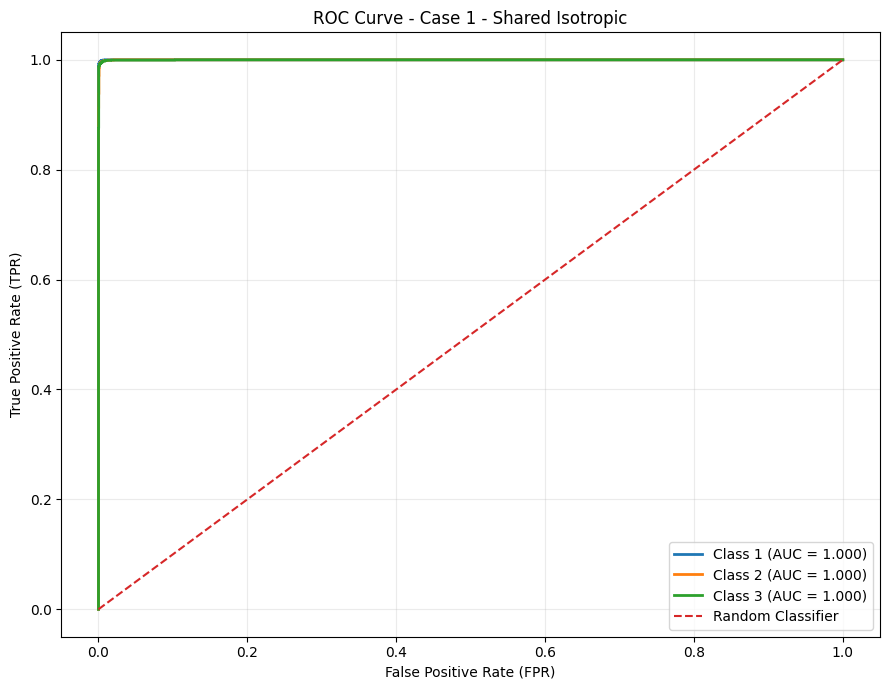

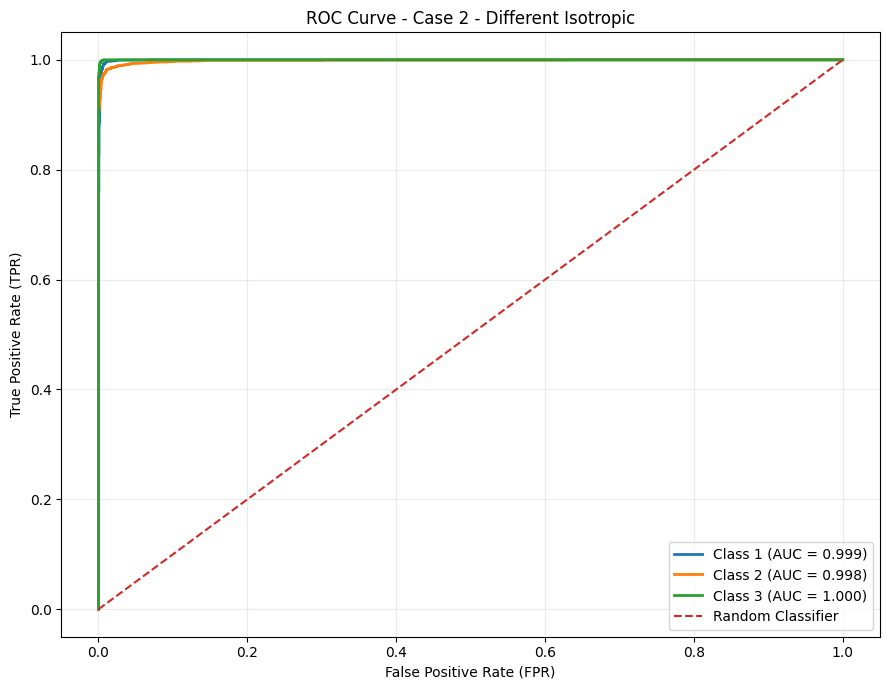

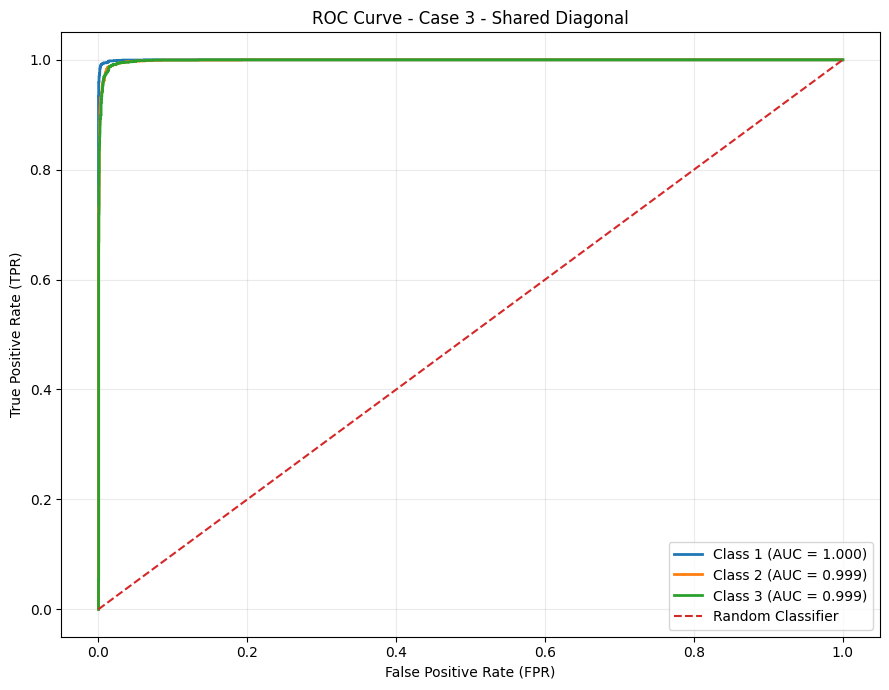

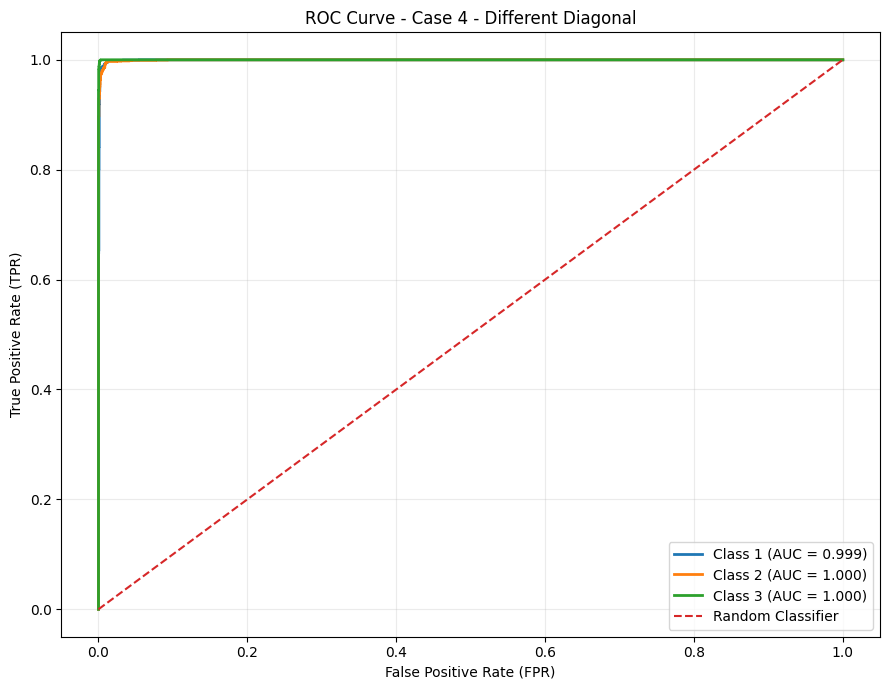

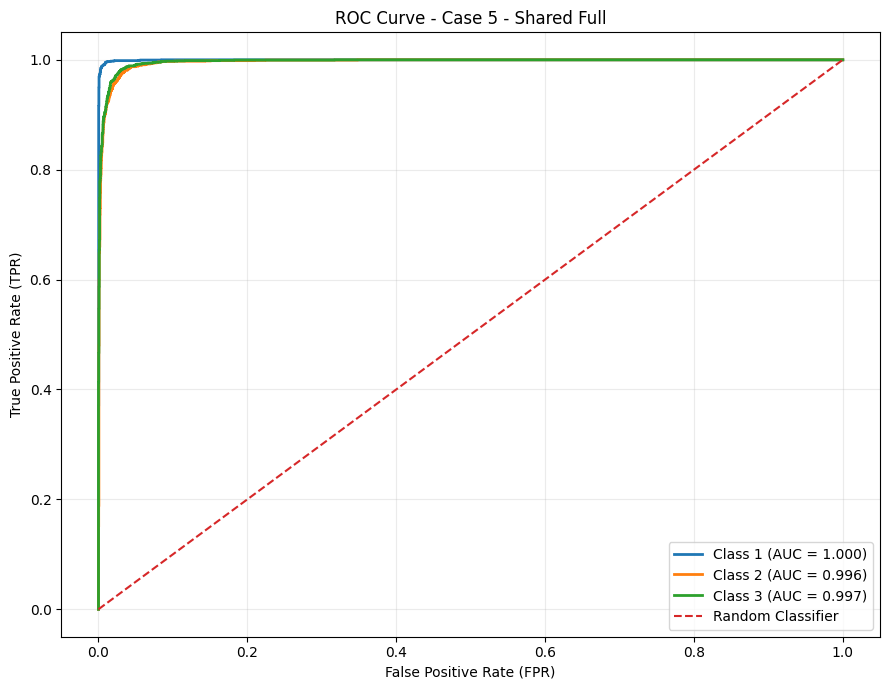

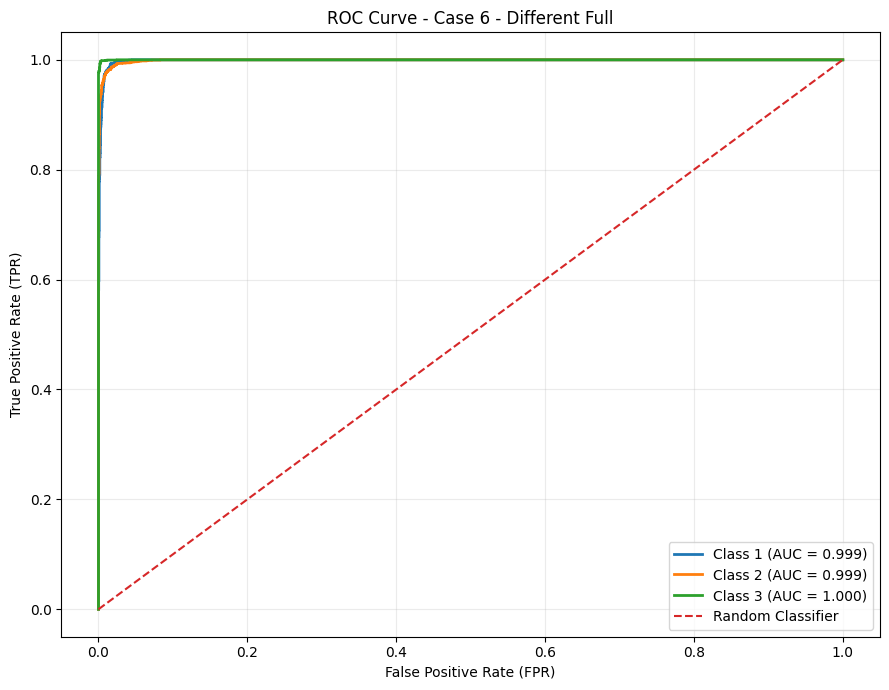

In [ ]:
# ROC Ploting
part1_cases = [("Case 1 - Shared Isotropic", COV_SHARED_ISO, "shared_isotropic"),
               ("Case 2 - Different Isotropic", COV_DIFFERENT_ISO, "different_isotropic"),
               ("Case 3 - Shared Diagonal", COV_SHARED_DIAGONAL, "shared_diagonal"),
               ("Case 4 - Different Diagonal", COV_DIFFERENT_DIAGONAL, "different_diagonal"),
               ("Case 5 - Shared Full", COV_SHARED_FULL, "shared_full"),
               ("Case 6 - Different Full", COV_DIFFERENT_FULL, "different_full")
              ]
for (case_name, covariance_list, covariance_case) in part1_cases:
    X_case, y_case = create_dataset(covariance_list)

    # Train-test split
    (X_train_case, y_train_case, X_test_case, y_test_case) = train_test_split_manual(X_case, y_case)

    # Estimate Gaussian parameters
    (means_case, covariances_case) = build_model(X_train_case, y_train_case, covariance_case)
    plt.figure(figsize=(9, 7))

    for class_id in range(3):
        scores = log_probability(X_test_case, means_case[class_id], covariances_case[class_id])
        fpr, tpr = calculate_roc(y_test_case, scores, class_id)

        # Calculate AUC
        auc = calculate_auc(fpr, tpr)
        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=(
                f"Class {class_id + 1} "
                f"(AUC = {auc:.3f})"
            )
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1.5,
        label="Random Classifier"
    )
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title(f"ROC Curve - {case_name}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

PART 2

In [4]:
# PART 2
np.random.seed(12)
file_name = "trian.txt"
data = np.loadtxt(file_name, delimiter=",")
X = data[:, 0:2]
y = data[:, 2].astype(int)
print("Number of samples:", len(X))
print("Classes:", np.unique(y))

classes = np.unique(y)
print("\nSamples in each class:")
for c in classes:
    print(f"Class {c}:", np.sum(y == c))

Number of samples: 1050
Classes: [1 2 3]

Samples in each class:
Class 1: 350
Class 2: 350
Class 3: 350


In [5]:
# 80% Training AND 20% Testing
train_X = []
train_y = []

test_X = []
test_y = []

for c in classes:
    class_points = X[y == c]
    indices = np.random.permutation(len(class_points))
    class_points = (class_points[indices])
    split = int(0.80 * len(class_points))

    train_X.append(class_points[:split])
    test_X.append(class_points[split:])

    train_y.append(np.full( split, c))
    test_y.append(np.full( len(class_points) - split, c))

X_train = np.vstack(train_X)
y_train = np.concatenate(train_y)

X_test = np.vstack(test_X)
y_test = np.concatenate(test_y)
print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))

#The training data is used to estimate each Gaussian class mean and covariance using MLE
#The testing data is reserved to evaluate classification performance.


Training samples: 840
Testing samples : 210


In [ ]:
# MLE estimmation
def calculate_mle_mean(points):
    return np.mean(points, axis=0)

def calculate_mle_covariance(points, mean):
    centered = (points - mean)
    return (centered.T @ centered) / len(points)

# Estimate parameters
means = {}
covariances = {}
print("\n")
print("=" * 65)
print("MLE PARAMETER ESTIMATION")
print("=" * 65)

for c in classes:
    class_training_data = X_train[y_train == c]
    mean = calculate_mle_mean(class_training_data)
    covariance = (calculate_mle_covariance( class_training_data, mean))
    means[c] = mean
    covariances[c] = covariance
    print(f"\nClass {c}")
    print("MLE Mean:")
    print(np.round( mean, 4))
    print("MLE Covariance:")
    print(np.round( covariance, 4))



MLE PARAMETER ESTIMATION

Class 1
MLE Mean:
[ 591.2411 1441.2624]
MLE Covariance:
[[24052.3713 -4028.5564]
 [-4028.5564 48674.3427]]

Class 2
MLE Mean:
[ 343.6866 2035.3589]
MLE Covariance:
[[ 6295.7382 -6580.945 ]
 [-6580.945  40633.9336]]

Class 3
MLE Mean:
[ 405.657  1200.9873]
MLE Covariance:
[[ 18779.9629  26963.8359]
 [ 26963.8359 136415.6651]]


In [ ]:
# Gaussian log likelihood
def gaussian_log_probability(points, mean, covariance):
    covariance = (covariance + 1e-10 * np.eye(2))
    difference = (points - mean)
    inverse_covariance = (np.linalg.inv( covariance))
    determinant = (np.linalg.det( covariance))

    mahalanobis_distance = np.sum((difference @ inverse_covariance) * difference, axis=1)
    return -0.5 * (2 * np.log(2 * np.pi) + np.log(determinant) + mahalanobis_distance)

In [ ]:
# Classification
def classify(points):
    probability_values = []
    for c in classes:
        score = (gaussian_log_probability( points, means[c], covariances[c]))
        probability_values.append(score)
    probability_values = np.array(probability_values)
    best_class_index = np.argmax(probability_values, axis=0)
    return classes[best_class_index]

In [ ]:
# Confusion matrix
predicted_labels = classify(X_test)
confusion = np.zeros((len(classes), len(classes)),dtype=int)
class_to_index = {c: i for i, c in enumerate(classes)}

for actual, predicted in zip(y_test, predicted_labels):
    row = class_to_index[actual]
    column = class_to_index[predicted]
    confusion[row, column] += 1
print("\n")
print("=" * 65)
print("CONFUSION MATRIX")
print("=" * 65)
print(confusion)
accuracy = (np.trace(confusion) / np.sum(confusion))
print("\nAccuracy:",f"{accuracy * 100:.2f}%")



CONFUSION MATRIX
[[63  2  5]
 [ 4 64  2]
 [11  2 57]]

Accuracy: 87.62%


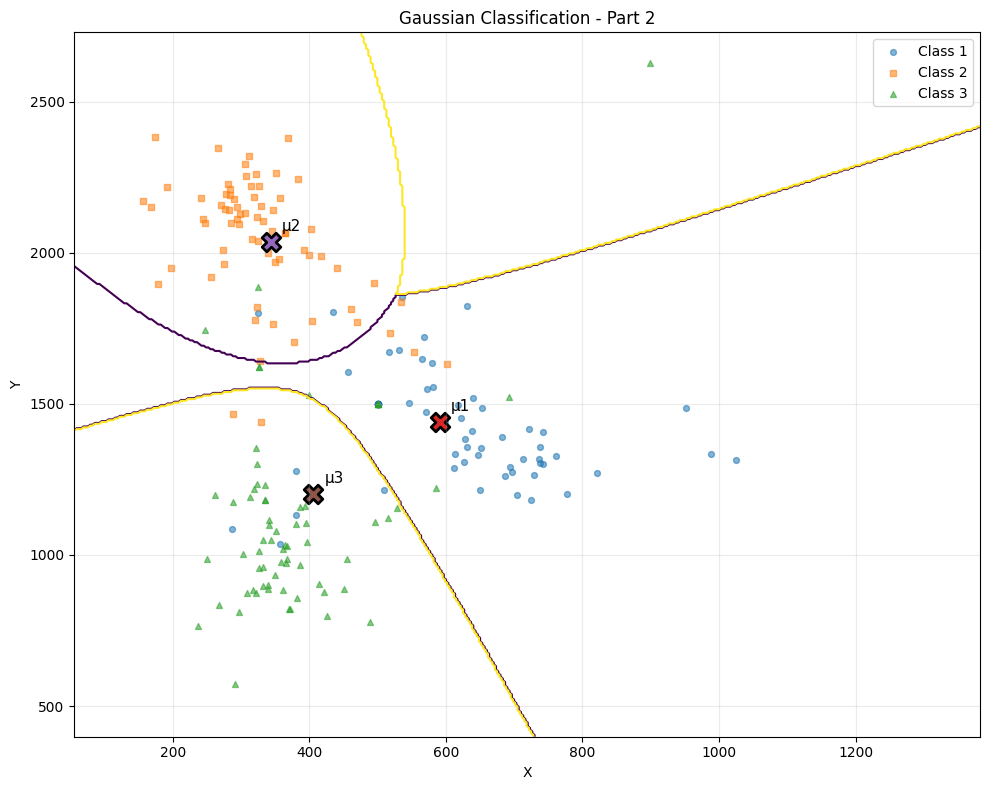

In [ ]:
# Decision Boundary
x_min = (X[:, 0].min() - 100)
x_max = (X[:, 0].max() + 100)

y_min = (X[:, 1].min() - 100)
y_max = (X[:, 1].max() + 100)

grid_x = np.linspace(x_min, x_max, 400)
grid_y = np.linspace(y_min, y_max, 400)

xx, yy = np.meshgrid(grid_x, grid_y)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])
grid_prediction = classify(grid_points)
grid_prediction = (grid_prediction.reshape(xx.shape))


plt.figure(figsize=(10, 8))
plt.contour(
    xx,
    yy,
    grid_prediction,
    levels=[
        1.5,
        2.5
    ],
    linewidths=1.5
)
markers = ["o", "s", "^", "D", "P"]
for i, c in enumerate(classes):
    test_points = X_test[y_test == c]
    plt.scatter(
        test_points[:, 0],
        test_points[:, 1],
        marker=markers[i % len(markers)],
        s=18,
        alpha=0.55,
        label=f"Class {c}"
    )

# MLE means
for c in classes:
    mean = means[c]
    plt.scatter(
        mean[0],
        mean[1],
        marker="X",
        s=180,
        edgecolors="black",
        linewidths=2
    )
    plt.annotate(
        f"μ{c}",
        mean,
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11
    )
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Gaussian Classification - Part 2")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

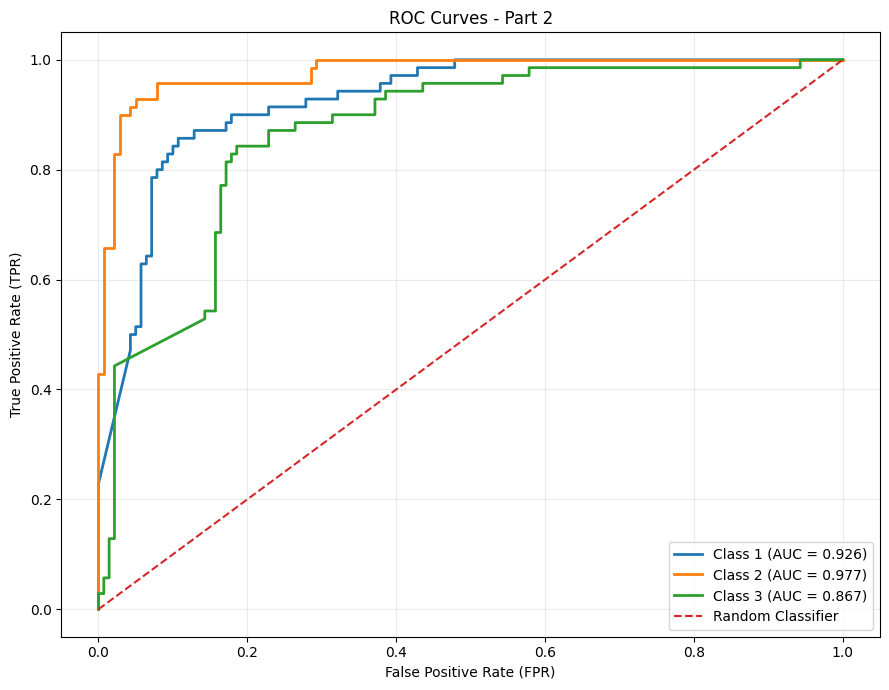



FINAL RESULT
Training samples : 840
Testing samples  : 210
Correct predictions: 184
Incorrect predictions: 26
Final Accuracy: 87.62%


In [ ]:
# ROC
plt.figure(figsize=(9, 7))
for c in classes:
    scores = (gaussian_log_probability(X_test, means[c], covariances[c]))
    fpr, tpr = calculate_roc(y_test, scores, c)
    auc = calculate_auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"Class {c} "
            f"(AUC = {auc:.3f})"
        )
    )
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves - Part 2")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("\n")
print("=" * 65)
print("FINAL RESULT")
print("=" * 65)
print("Training samples :", len(X_train))
print("Testing samples  :",
    len(X_test)
)

print(
    "Correct predictions:",
    np.trace(confusion)
)

print(
    "Incorrect predictions:",
    len(X_test)
    -
    np.trace(confusion)
)

print(
    "Final Accuracy:",
    f"{accuracy * 100:.2f}%"
)